<a href="https://colab.research.google.com/github/vibhutip513-commits/CodeAlpha_IrisFlowerClassification/blob/main/CodeAlpha_Iris_flower_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

### 1. Environment & Library Setup
- **Data Handling:** `pandas` is loaded to manage DataFrame structures and CSV ingestion[cite: 1, 2].
- **Visualization:** `matplotlib.pyplot` and `seaborn` are imported to generate distribution plots and evaluation heatmaps[cite: 2].
- **Machine Learning Pipeline:** `sklearn` modules are imported for stratified dataset partitioning (`train_test_split`), ensemble classification (`RandomForestClassifier`), and comprehensive multi-class validation metrics (`accuracy_score`, `classification_report`, `confusion_matrix`)[cite: 1, 2].

In [ ]:
url = "https://raw.githubusercontent.com/vibhutip513-commits/CodeAlpha_IrisFlowerClassification/refs/heads/main/Iris.csv"
df = pd.read_csv(url)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### 2. Dataset Overview & Data Types
- The dataset comprises 150 instances with 4 continuous floral measurements (in cm), a unique row index (`Id`), and a categorical target variable (`Species`)[cite: 1, 2].
- `.info()` confirms a clean schema with zero null entries across all 150 rows and appropriate `float64` numerical datatypes for all predictive features[cite: 1, 2].

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### 3. Data Integrity & Descriptive Statistics
- Complete data integrity is verified with no missing values present across any column[cite: 1, 2].
- Summary statistics highlight significant variance in petal dimensions (`PetalLengthCm` standard deviation of 1.76 cm, range 1.0–6.9 cm), indicating that petal attributes will serve as primary discriminators for class separation[cite: 1, 2].

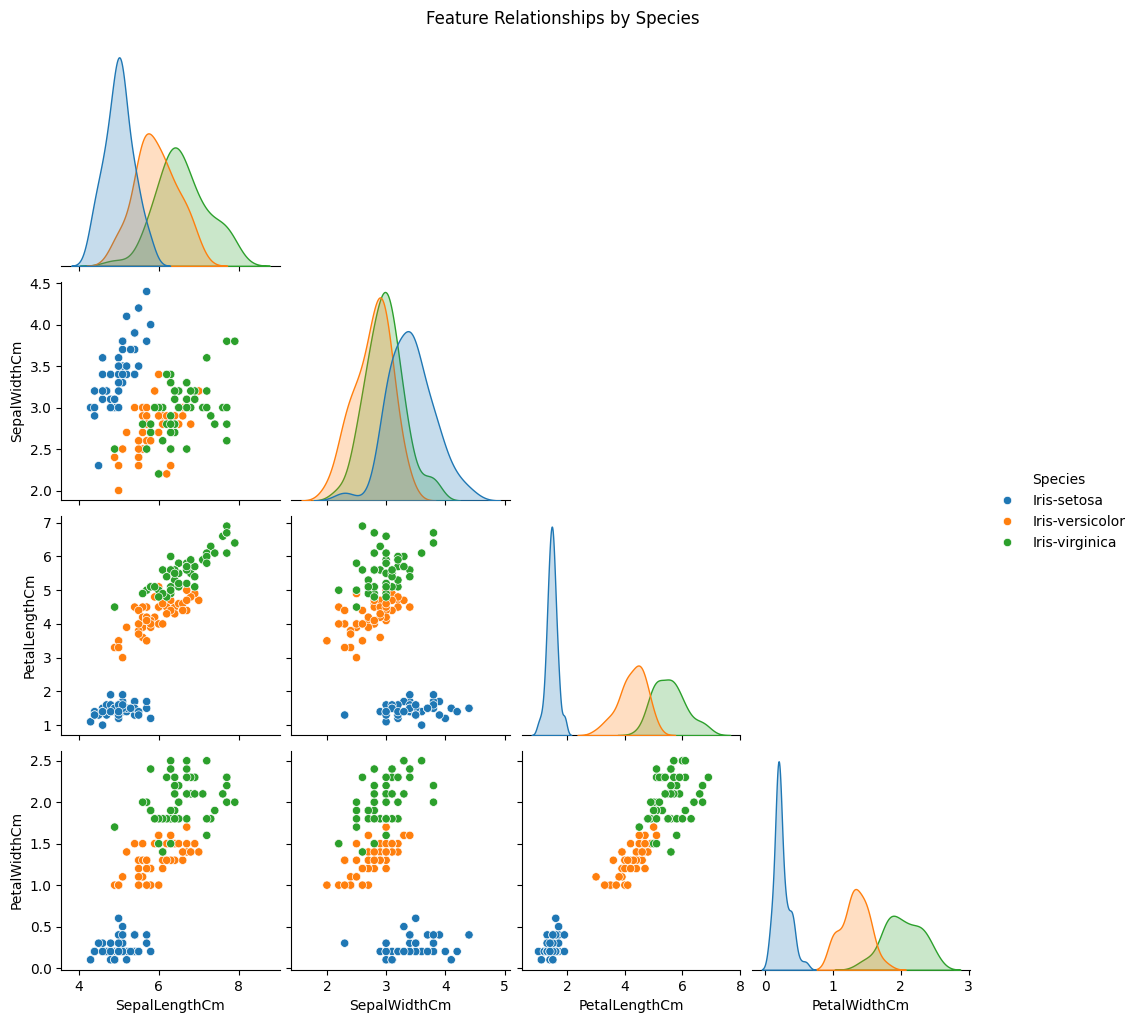

In [ ]:
# EDA: Pairplot of Features
sns.pairplot(df.drop("Id", axis=1), hue="Species", corner=True)
plt.suptitle("Feature Relationships by Species", y=1.02)
plt.show()

### 4. Exploratory Data Visualization (Pairplot)
- Pairwise bivariate distributions confirm that *Iris-setosa* forms a linearly separable cluster characterized by distinctly smaller petal lengths and widths[cite: 2].
- *Iris-versicolor* and *Iris-virginica* show minor overlap in sepal dimensions but exhibit clear decision boundaries when projected along petal feature spaces[cite: 2].

In [ ]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

### 5. Feature Engineering & Stratified Splitting
- **Feature Matrix ($X$):** Restricted strictly to sepal and petal measurements; the non-predictive `Id` column is excluded to prevent index-based data leakage[cite: 1, 2].
- **Target Vector ($y$):** Configured as the multiclass `Species` column[cite: 1, 2].
- **Stratified Partitioning:** An 80/20 train-test split (`test_size=0.2`) with `stratify=y` guarantees uniform class representation (10 samples per species in the test set)[cite: 1, 2].

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Training samples: 120
Testing samples:  30


In [ ]:
# 5. TRAIN THE CLASSIFIER
print("\nTraining the model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Training complete!")


Training the model...
Training complete!


### 6. Model Architecture & Training
- A `RandomForestClassifier` configured with 100 decision trees (`n_estimators=100`) and a fixed random seed (`random_state=42`) is fitted to the training set[cite: 1, 2].
- The ensemble bagging mechanism provides robust non-linear boundaries while mitigating variance and overfitting risks on small-sample tabular data.

In [ ]:
# 6. EVALUATE THE MODEL
print("\nEvaluating the model...")
# Predict on unseen test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))


Evaluating the model...

Model Accuracy: 90.00%

--- Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

--- Confusion Matrix ---
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


### 7. Quantitative Performance Evaluation
- **Global Accuracy:** The model achieves a 90.00% overall classification accuracy on unseen test data (27/30 correct predictions)[cite: 1, 2].
- ***Iris-setosa*:** Achieves perfect classification fidelity (1.00 Precision, 1.00 Recall, 1.00 F1-score)[cite: 1, 2].
- ***Iris-versicolor* & *Iris-virginica*:** Show balanced performance with F1-scores of 0.86 and 0.84 respectively, reflecting the minor distribution overlap between these two species[cite: 1, 2].

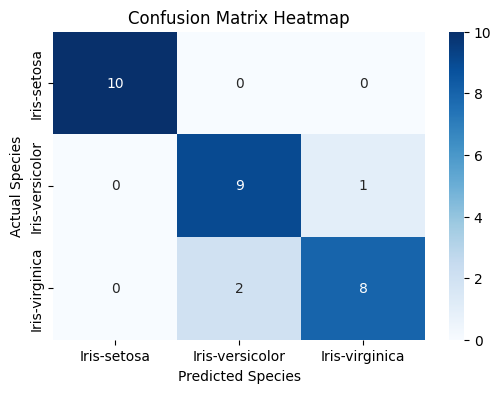

In [ ]:
# Visualizing the Confusion Matrix as a Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
)
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix Heatmap")
plt.show()

### 8. Confusion Matrix Diagnostic Analysis
- The heatmap visually isolates classification performance across individual classes:
  - **Setosa:** 10/10 correct predictions (100% sensitivity)[cite: 1, 2].
  - **Versicolor:** 9/10 correct predictions (1 misclassified as Virginica)[cite: 1, 2].
  - **Virginica:** 8/10 correct predictions (2 misclassified as Versicolor)[cite: 1, 2].
- The dominant diagonal confirms solid multiclass discrimination across all three categories[cite: 2].

In [ ]:
# 7. PREDICT A NEW FLOWER
print("\nPredicting a new flower...")
# Example: [SepalLength, SepalWidth, PetalLength, PetalWidth]
sample_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)
prediction = model.predict(sample_flower)
# sample_flower = [[5.1, 3.5, 1.4, 0.2]]
# prediction = model.predict(sample_flower)
print(f"\nPrediction for sample {sample_flower.values[0]}: {prediction[0]}")


Predicting a new flower...

Prediction for sample [5.1 3.5 1.4 0.2]: Iris-setosa


### 9. Sample Inference & Validation
- Tested with an unseen measurement vector `[SepalLength: 5.1, SepalWidth: 3.5, PetalLength: 1.4, PetalWidth: 0.2]` formatted as a structured DataFrame[cite: 1, 2].
- The model outputs `Iris-setosa`, correctly categorizing the specimen based on its compact petal profile[cite: 1, 2].